# Time Series Analisys on Geoespatial Data with Python


Author: João Otavio Nascimento Firigato

email: joaootavionf007@gmail.com

LinkedIn: https://www.linkedin.com/in/jo%C3%A3o-otavio-firigato-4876b3aa/


## First instructions:

✅ Access the link to join our private WhatsApp community for students: https://chat.whatsapp.com/EPn27ZgR07lF3e1vnj8FiI


❗ It is important to access the Whatsapp Group to get the Colab Notebooks, as the PDF files are protected from text copying.




# Chapter 15 - Predicting future NDVI scenarios with Prophet

Let's perform a prediction of future scenarios for each pixel of an NDVI image with Prophet. We start by installing rasterio and importing the necessary libraries:

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 88.5 MB/s eta 0:00:00


In [ ]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap
import geopandas as gpd
import warnings
import os
import rasterio
from prophet import Prophet
warnings.filterwarnings('ignore')

We will get the data from GEE. Then let's authenticate and initialize our project:

In [ ]:
ee.Authenticate()
ee.Initialize(project='my-project-1527255156007')

Let's connect Drive to get our analysis area:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Link to Dataset: https://drive.google.com/drive/folders/1nnw4UJqcNuHx7c6amCs1J86ZeukIF_Ck?usp=sharing

In [ ]:
path_aoi = '/content/drive/MyDrive/Datasets_TS/Prophet_pred/AOI.shp'

In [ ]:
gdf_aoi = gpd.read_file(path_aoi)

We convert the GeoDataFrame to a FeatureCollection to get the collection of images for that area:

In [ ]:
fc = geemap.geopandas_to_ee(gdf_aoi)

In [ ]:
S2_coll = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)).filterDate('2023-01-01','2024-12-31').filterBounds(fc)

Let's generate a monthly NDVI series:

In [ ]:
def addNDVI(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

S2_coll = S2_coll.map(addNDVI)

In [ ]:
!mkdir sentinel_2_by_month

In [ ]:
months = ee.List.sequence(1, 12)
years = ee.List.sequence(2023, 2024)

def monthly(collection):
  img_coll = ee.ImageCollection([])
  for y in years.getInfo():
    for m in months.getInfo():
      filtered = collection.filter(ee.Filter.calendarRange(y, y, 'year')).filter(ee.Filter.calendarRange(m, m, 'month'))
      filtered = filtered.median().clip(fc.geometry())
      img_coll = img_coll.merge(filtered.set('year', y).set('month', m).set('system:time_start', ee.Date.fromYMD(y, m, 1).format('YYYY-MM-dd').getInfo()))
      img_coll = img_coll.select('NDVI')
  return img_coll

In [ ]:
monthly_s2_collection = monthly(S2_coll)
print('Total number of images :', monthly_s2_collection.size().getInfo())

Total number of images : 24


Let's visualize the images with geemap:

In [ ]:
Map = geemap.Map()
Map.centerObject(fc,14)

# Function to display an image on the map
def display_image(image):
  vis_params = {
      'bands': 'NDVI',
      'min': 0,
      'max': 1,
      'palette': ['red', 'yellow', 'green']
  }
  Map.addLayer(image, vis_params, str(image.get('system:time_start').getInfo()))

# Iterate through the yearly image collection and display each image
for i in range(monthly_s2_collection.size().getInfo()):
    image = ee.Image(monthly_s2_collection.toList(monthly_s2_collection.size()).get(i))
    display_image(image.select('NDVI'))


Map

We will download the images:

In [ ]:
geemap.ee_export_image_collection(
    monthly_s2_collection,
    out_dir="./sentinel_2_by_month",
    scale=20,
    crs='EPSG:4326',
    region=fc.geometry(),
    filenames= monthly_s2_collection.aggregate_array("system:time_start").getInfo(),
    file_per_band=False,
    timeout=300,
    proxies=None
)

Let's open the .tif images and create a dataframe with the image information:

In [ ]:
im_list = []
index = []
path = '/content/sentinel_2_by_month'
for name in os.listdir(path):
  path_full = os.path.join(path,name)
  ds = rasterio.open(path_full, 'r')
  im = ds.read(1)
  im_list.append(im)
  index.append(name.split('.')[0])

In [ ]:
im_list = np.array(im_list)

In [ ]:
im_list.shape

(24, 54, 78)

In [ ]:
n = im_list.shape[0]
l = im_list.shape[1]
c = im_list.shape[2]

In [ ]:
im_data = im_list.reshape(n, l*c)

In [ ]:
df_full = pd.DataFrame(im_data, index=index)

In [ ]:
df_full

,0,1,2,3,4,5,6,7,8,9,...,4202,4203,4204,4205,4206,4207,4208,4209,4210,4211
2023-01-01,0.621775,0.624945,0.508253,0.084996,0.044025,0.043295,0.038271,0.030314,0.027542,0.034211,...,0.199644,0.181377,0.216450,0.253223,0.262572,0.273760,0.262225,0.258621,0.232240,0.237217
2023-02-01,0.577178,0.574377,0.441229,0.000191,-0.048634,-0.046028,-0.052288,-0.055950,-0.058065,-0.039004,...,0.236167,0.219052,0.249370,0.316946,0.335443,0.350701,0.306332,0.301147,0.244816,0.261636
2023-03-01,0.472126,0.485622,0.411556,0.024422,-0.006206,-0.010561,-0.015067,-0.012426,-0.011912,-0.003133,...,0.184900,0.190875,0.216366,0.257275,0.276033,0.278689,0.263965,0.254753,0.229540,0.239704
2023-04-01,0.828339,0.824505,0.674976,0.080230,0.018500,0.016267,0.009555,0.000570,-0.001887,0.017462,...,0.205303,0.211189,0.234985,0.272330,0.299557,0.294885,0.286066,0.261335,0.236928,0.236122
2023-05-01,0.867662,0.859656,0.696135,0.087045,0.019488,0.024220,0.016268,0.010036,0.010672,0.028574,...,0.311016,0.319089,0.348565,0.386655,0.414360,0.385613,0.343243,0.319551,0.287281,0.272305
2023-06-01,0.385888,0.385797,0.320232,0.072735,0.041004,0.036286,0.030155,0.029684,0.029825,0.043021,...,0.104875,0.109108,0.112682,0.141107,0.146682,0.157765,0.167795,0.167346,0.149652,0.146670
2023-07-01,0.291512,0.302030,0.276873,0.075436,0.038321,0.045361,0.039062,0.031001,0.033245,0.044712,...,0.143128,0.139991,0.156138,0.186683,0.198476,0.209408,0.259204,0.236780,0.227365,0.231439
2023-08-01,0.127025,0.135568,0.126012,0.068550,0.038421,0.046344,0.036536,0.034368,0.032454,0.047148,...,0.153380,0.135255,0.131034,0.156926,0.135936,0.126114,0.130514,0.117965,0.101289,0.079725
2023-09-01,0.075601,0.072386,0.088195,0.042271,0.032903,0.035369,0.037031,0.033807,0.031100,0.032112,...,0.182431,0.180681,0.187811,0.198945,0.225157,0.210382,0.196837,0.197917,0.187951,0.206074
2023-10-01,0.074036,0.077673,0.078352,0.035823,0.007128,0.007274,0.004430,0.003337,0.002411,0.012269,...,0.164622,0.169885,0.191174,0.205013,0.238053,0.254272,0.229114,0.205958,0.201083,0.213050


In [ ]:
df_full.sort_index(inplace=True)

Let's now apply Prophet to one of the pixels in our area and check the result:

In [ ]:
new_test = df_full[1485].reset_index()
new_test.rename(columns={"index": "ds", 1485: "y"},inplace=True)
model = Prophet(yearly_seasonality=True)
model.fit(new_test)
forecast = model.make_future_dataframe(periods = 12, freq = 'M')
forecast = model.predict(forecast)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr5922kms/qvt3muqm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr5922kms/vjre7fq5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53732', 'data', 'file=/tmp/tmpr5922kms/qvt3muqm.json', 'init=/tmp/tmpr5922kms/vjre7fq5.json', 'output', 'file=/tmp/tmpr5922kms/prophet_modelllwhrk1u/prophet_model-20250409141021.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
14:10:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:10:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:

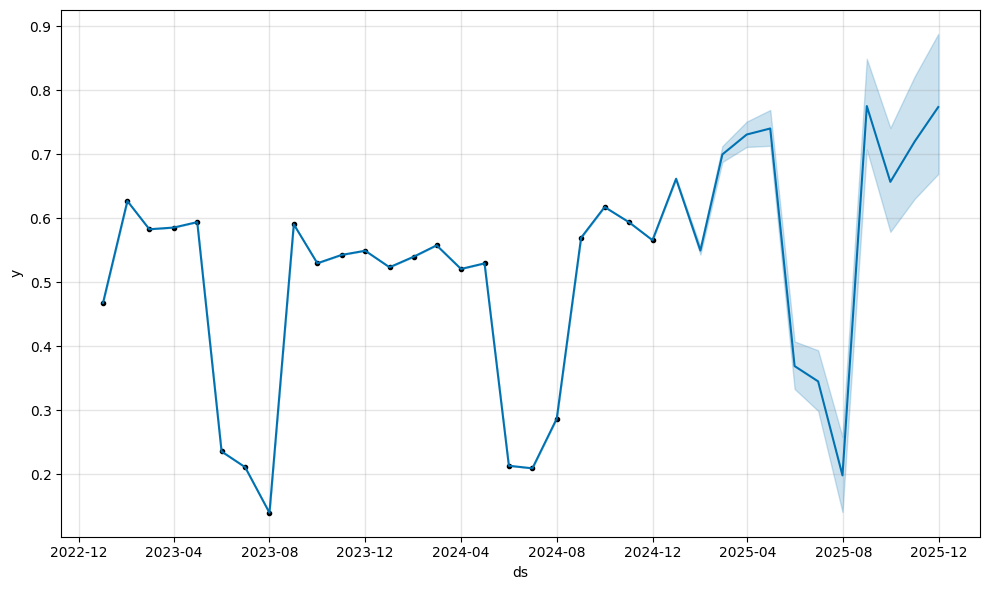

In [ ]:
fig1 = model.plot(forecast)


Let's then create some helper functions:

In [ ]:
def CreateTimeSeries(id):
    new_df = df_full[id].reset_index()
    new_df.rename(columns={"index": "ds", id: "y"},inplace=True)
    return new_df

In [ ]:
def run_prophet(id):
    timeserie = CreateTimeSeries(id)
    model = Prophet(yearly_seasonality=True)
    model.fit(timeserie)
    forecast = model.make_future_dataframe(periods = 12, freq = 'M')
    forecast = model.predict(forecast)
    return np.append(np.array([id]),forecast['yhat'].values.transpose())

We will use multiprocessing to speed up running Prophet on our data:

In [ ]:
columns_df = df_full.columns
from multiprocessing import Pool, cpu_count
print(f'Parallelism on {cpu_count()} CPU')
with Pool(cpu_count()) as p:
    predictions1  = list(p.imap(run_prophet, columns_df))

A saída de streaming foi truncada nas últimas 5000 linhas.
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50684', 'data', 'file=/tmp/tmpr5922kms/3ch6venp.json', 'init=/tmp/tmpr5922kms/bs5dm42y.json', 'output', 'file=/tmp/tmpr5922kms/prophet_modelbbcfutwg/prophet_model-20250410003445.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
00:34:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:34:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr5922kms/840d

After some time, we get the predictions:

In [ ]:
predictions1 = np.array(predictions1)

In [ ]:
predictions1.shape

(4212, 37)

In [ ]:
predictions1

array([[ 0.00000000e+00,  6.21775325e-01,  5.77176769e-01, ...,
        -4.81119166e-02,  1.00696824e+00,  1.04513038e+00],
       [ 1.00000000e+00,  6.24945168e-01,  5.74380557e-01, ...,
        -2.90436328e-02,  1.05104481e+00,  1.07746656e+00],
       [ 2.00000000e+00,  5.08252958e-01,  4.41234317e-01, ...,
         3.90125118e-02,  9.48924643e-01,  9.30870690e-01],
       ...,
       [ 4.20900000e+03,  2.58619876e-01,  3.01146927e-01, ...,
        -3.88394482e-02, -4.79584643e-02, -3.96750836e-02],
       [ 4.21000000e+03,  2.32240309e-01,  2.44815143e-01, ...,
        -2.44072081e-02, -1.33847756e-02, -1.89131959e-02],
       [ 4.21100000e+03,  2.37217791e-01,  2.61636927e-01, ...,
        -5.52227725e-02, -1.64659017e-02, -1.40835716e-02]])

And we generate the predicted date range:

In [ ]:
date_range = pd.date_range(start='2023-01-01', periods=36, freq='MS')

In [ ]:
date_range = date_range.strftime('%Y-%m-%d')

We generate a DataFrame with past data and predicted data:

In [ ]:
df_results = pd.DataFrame(predictions1[:,1:], columns=date_range)

In [ ]:
df_results

,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
0,0.621775,0.577177,0.472126,0.828341,0.867664,0.385888,0.291511,0.127023,0.075599,0.074037,...,0.287427,0.891678,1.019392,0.515810,0.555476,0.307458,0.246597,-0.048112,1.006968,1.045130
1,0.624945,0.574381,0.485624,0.824504,0.859653,0.385795,0.302032,0.135572,0.072388,0.077672,...,0.349995,0.907325,1.010350,0.512853,0.577143,0.333272,0.245521,-0.029044,1.051045,1.077467
2,0.508253,0.441234,0.411561,0.674975,0.696131,0.320227,0.276873,0.126018,0.088199,0.078351,...,0.336862,0.779409,0.854706,0.468321,0.550787,0.332403,0.285208,0.039013,0.948925,0.930871
3,0.081001,0.010697,0.017124,0.071416,0.078706,0.066821,0.073124,0.070183,0.047375,0.042949,...,-0.002130,0.086682,0.085294,0.093645,0.096119,0.089096,0.059187,0.039623,0.121093,0.094411
4,0.047237,-0.040567,-0.009773,0.014885,0.016299,0.038705,0.037135,0.038330,0.033617,0.008180,...,-0.032885,0.015780,0.007655,0.044751,0.036291,0.043048,0.036246,0.004079,0.056483,0.019874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4207,0.273760,0.350703,0.278688,0.294883,0.385613,0.157767,0.209408,0.126112,0.210382,0.254274,...,0.184267,0.209377,0.382416,0.068450,0.166508,0.028963,0.175573,0.186848,0.122889,0.157920
4208,0.265960,0.318887,0.257736,0.279495,0.337317,0.163572,0.257178,0.130756,0.198846,0.231968,...,0.034940,0.072470,0.190826,-0.096269,0.059775,-0.155510,-0.021795,0.029150,-0.017946,-0.004240
4209,0.258620,0.301147,0.254752,0.261335,0.319552,0.167347,0.236779,0.117964,0.197917,0.205958,...,0.009827,0.017316,0.146765,-0.120686,-0.004236,-0.211773,-0.056087,-0.038839,-0.047958,-0.039675
4210,0.232240,0.244815,0.229540,0.236929,0.287281,0.149652,0.227364,0.101290,0.187951,0.201083,...,0.041077,0.031120,0.125351,-0.127905,0.004022,-0.213690,-0.053768,-0.024407,-0.013385,-0.018913


Let's select some columns to visualize the evolution of NDVI to predicted NDVI:

In [ ]:
future_columns = df_results.columns[10:]

In [ ]:
df_results.columns

Index(['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01',
       '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01', '2023-10-01',
       '2023-11-01', '2023-12-01', '2024-01-01', '2024-02-01', '2024-03-01',
       '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
       '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01',
       '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01',
       '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
       '2025-12-01'],
      dtype='object')

In [ ]:
future_columns

Index(['2023-11-01', '2023-12-01', '2024-01-01', '2024-02-01', '2024-03-01',
       '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
       '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01',
       '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01',
       '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
       '2025-12-01'],
      dtype='object')

We can then convert the dataframe into images according to the selected dates and plot the NDVI images:

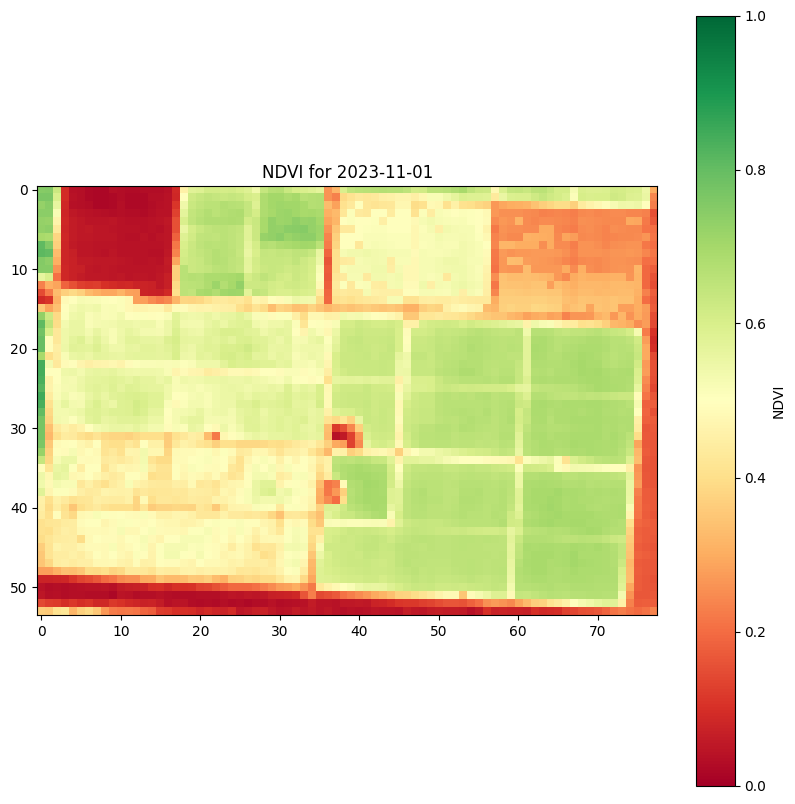

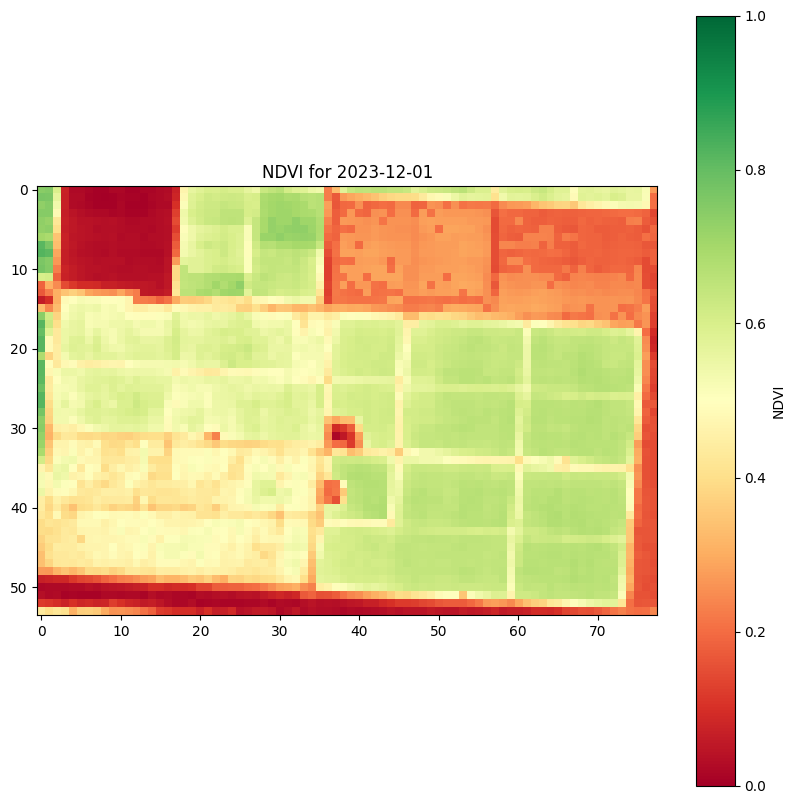

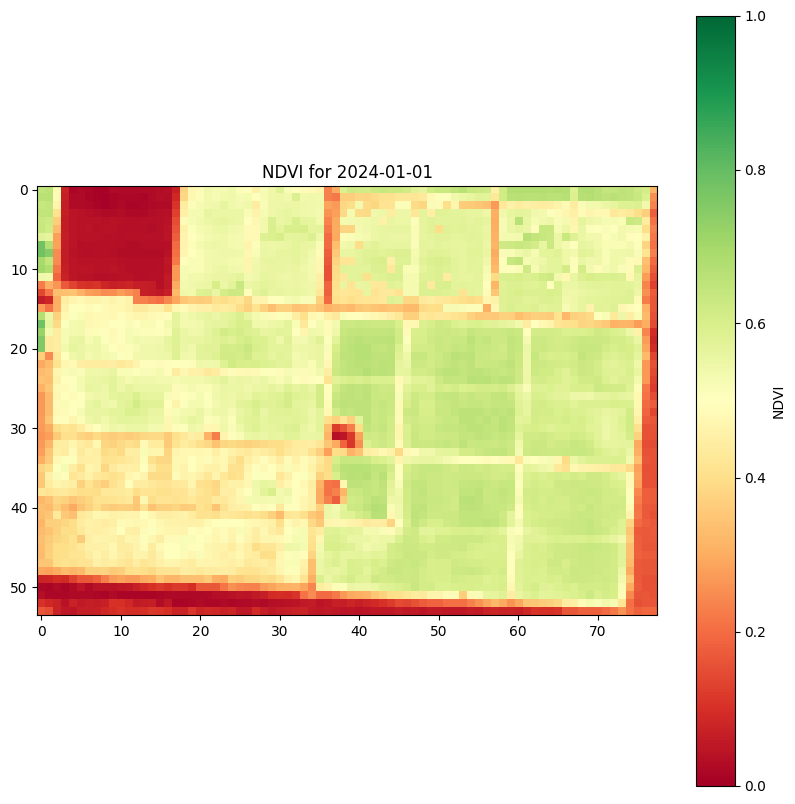

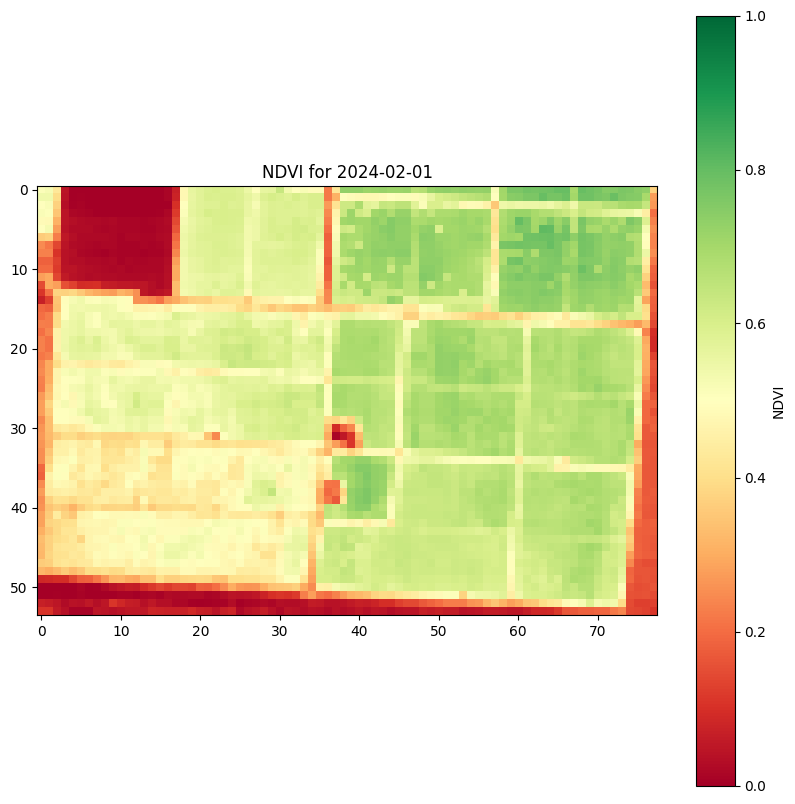

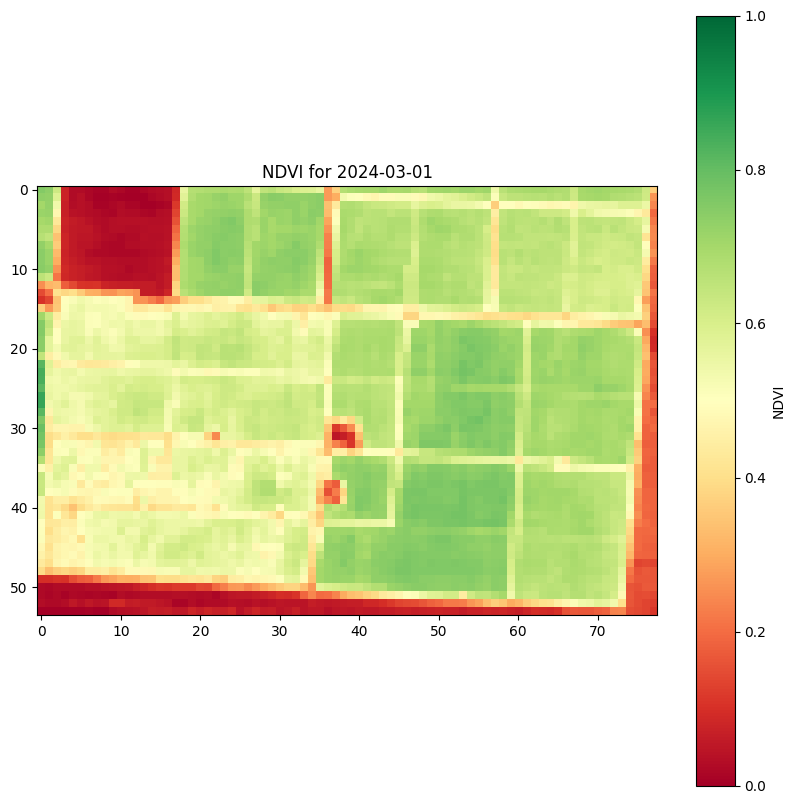

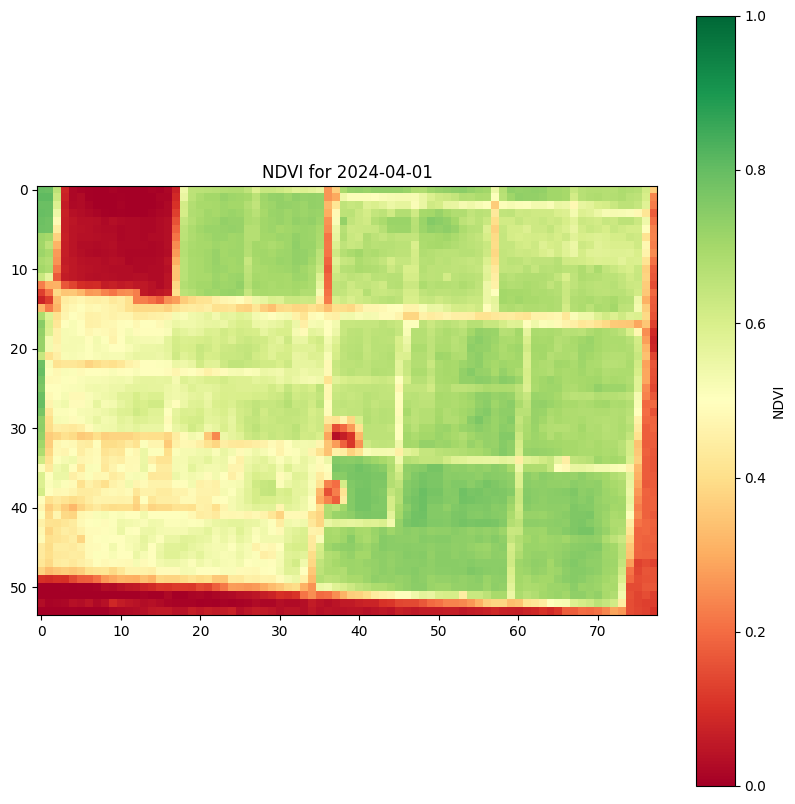

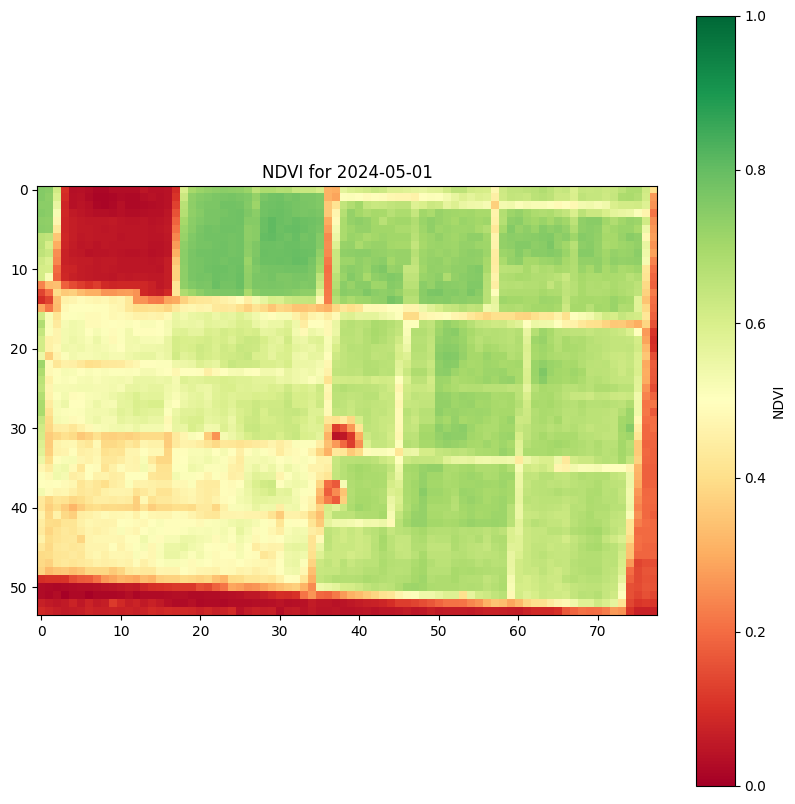

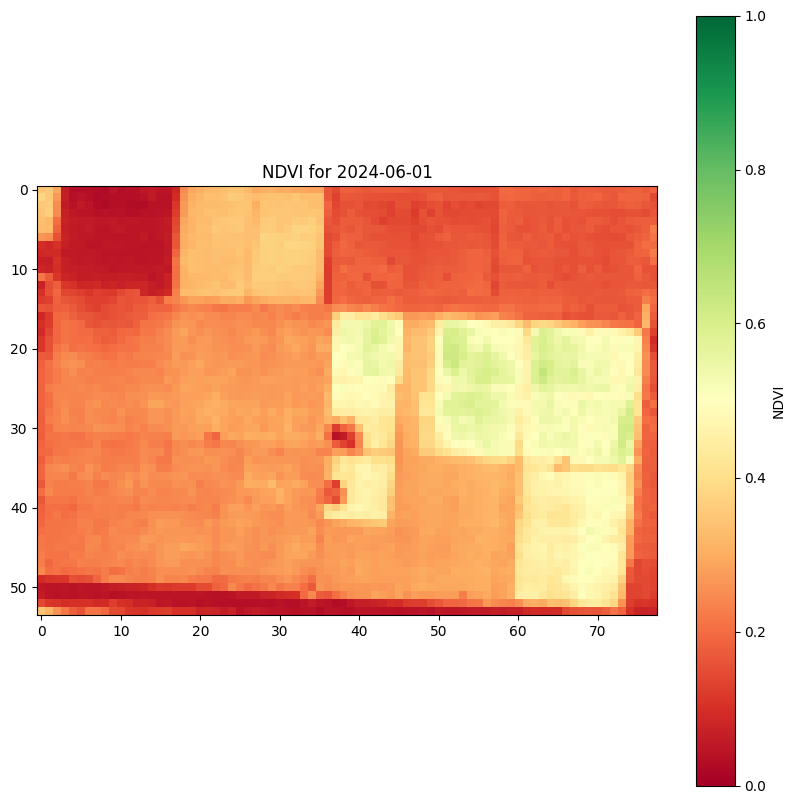

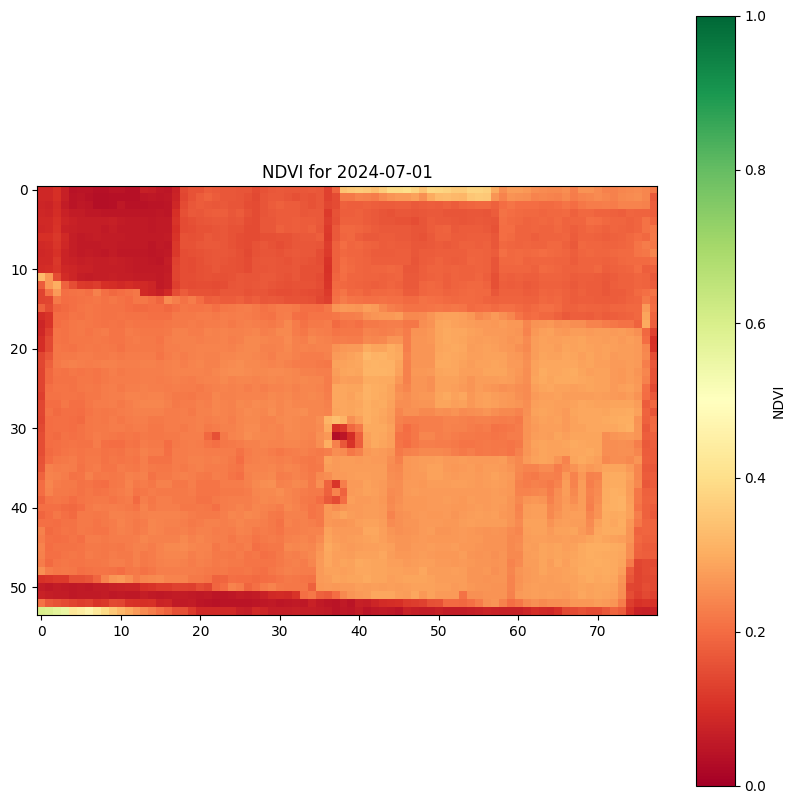

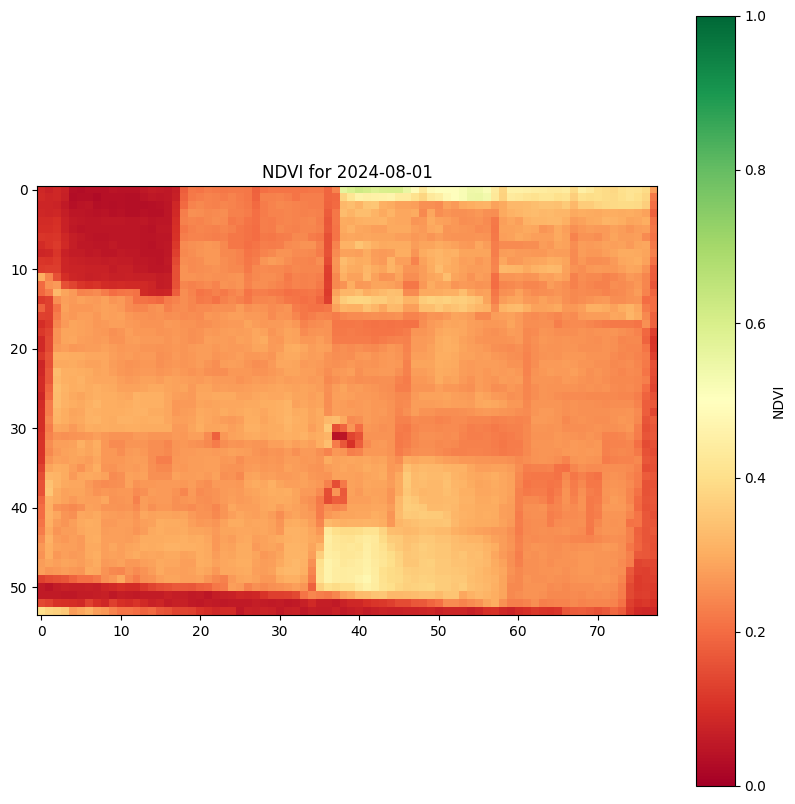

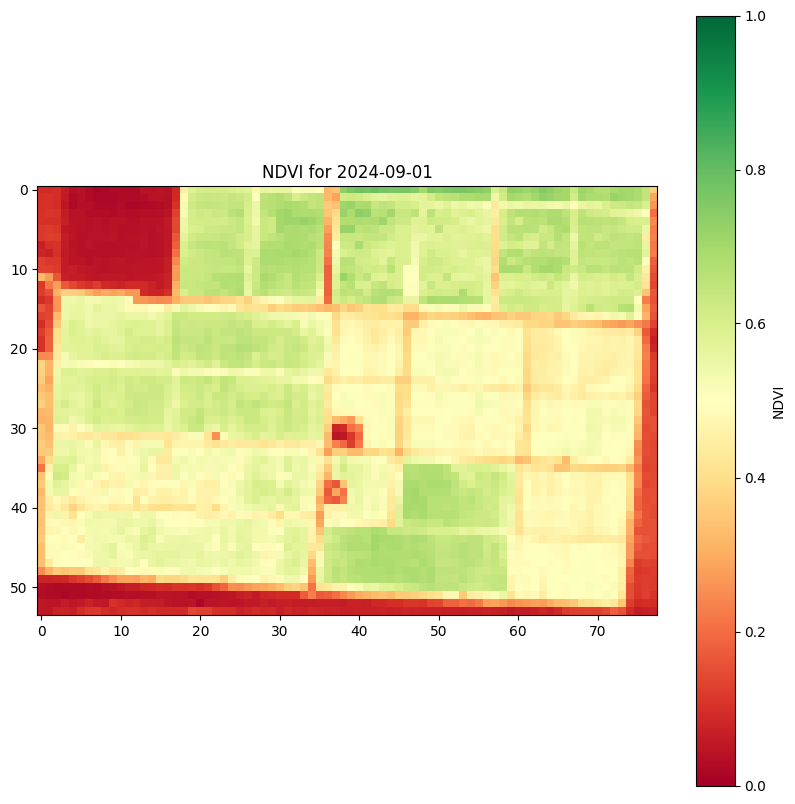

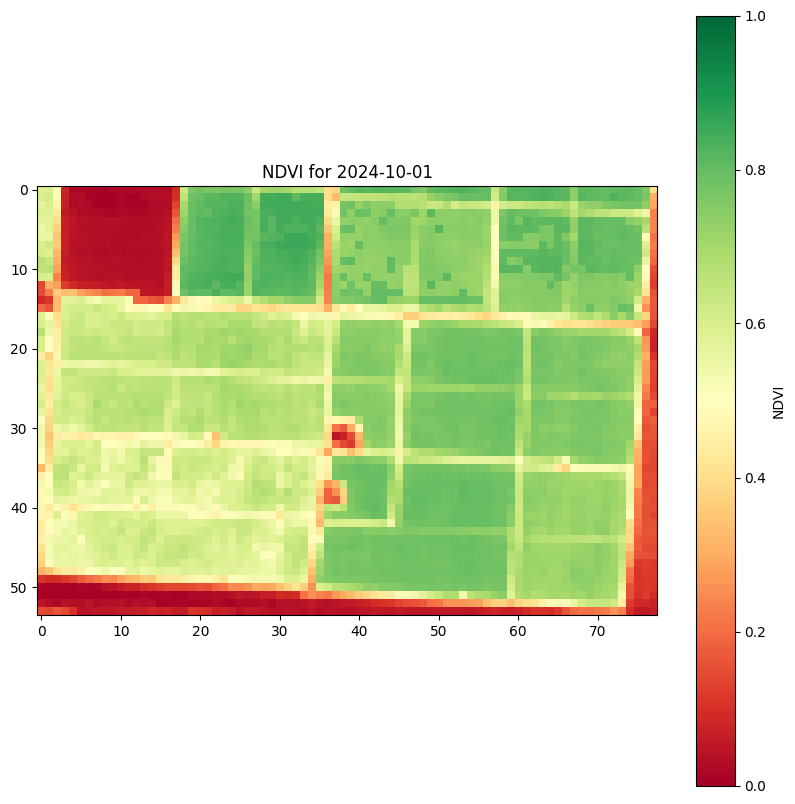

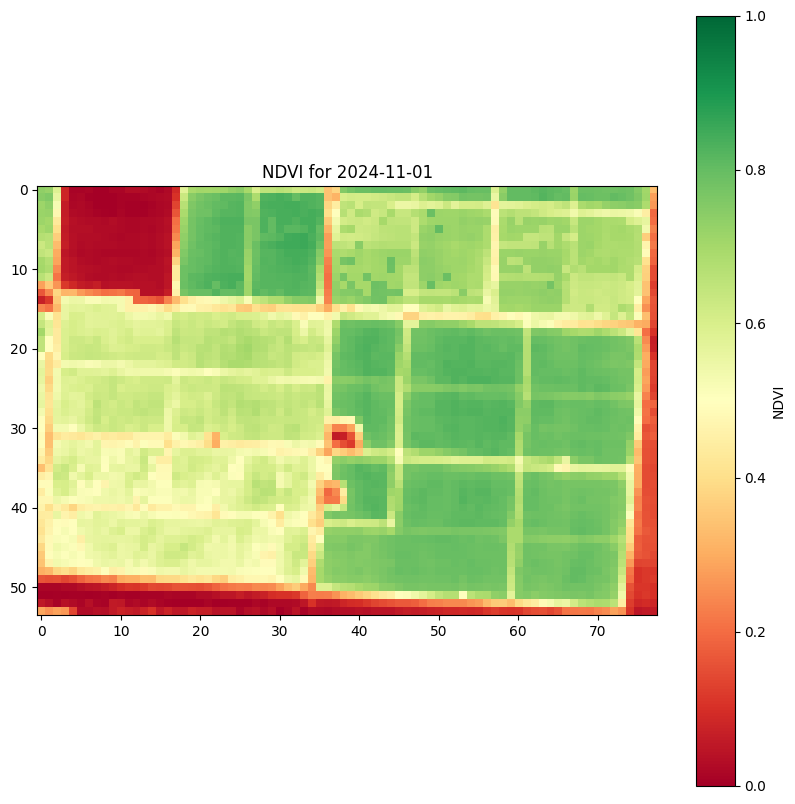

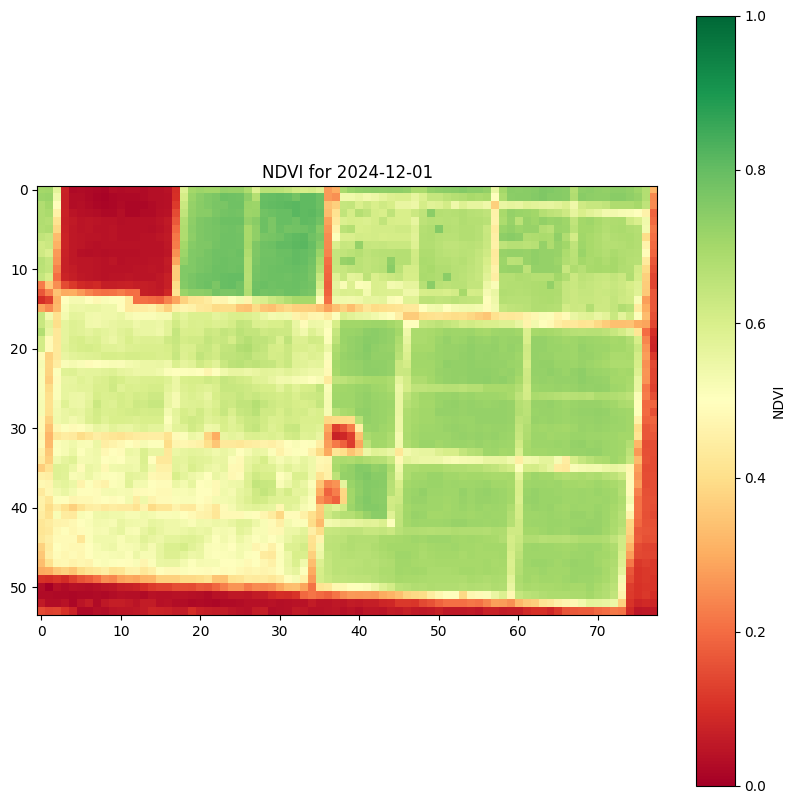

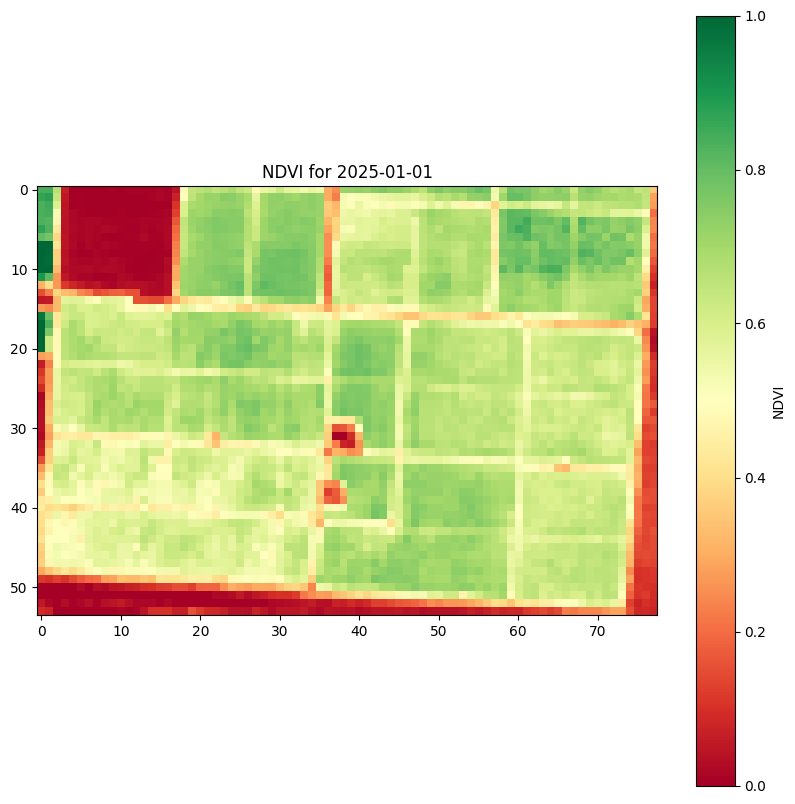

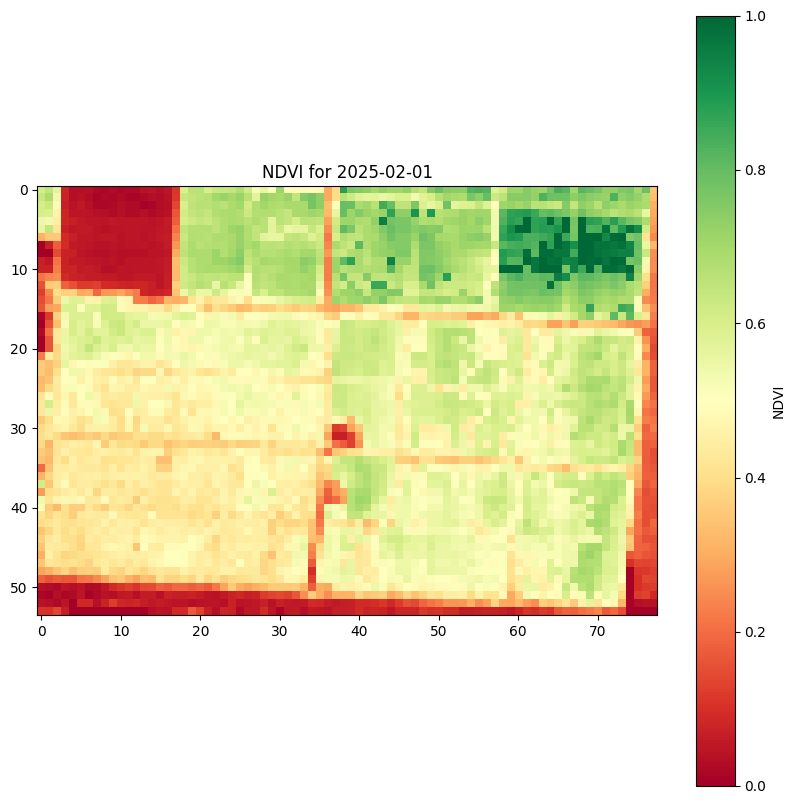

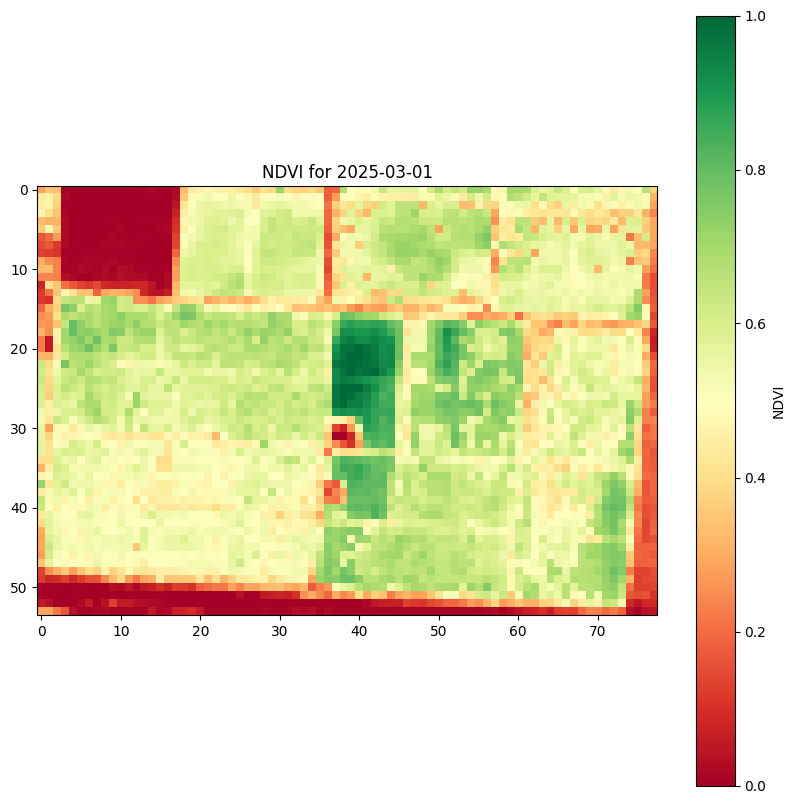

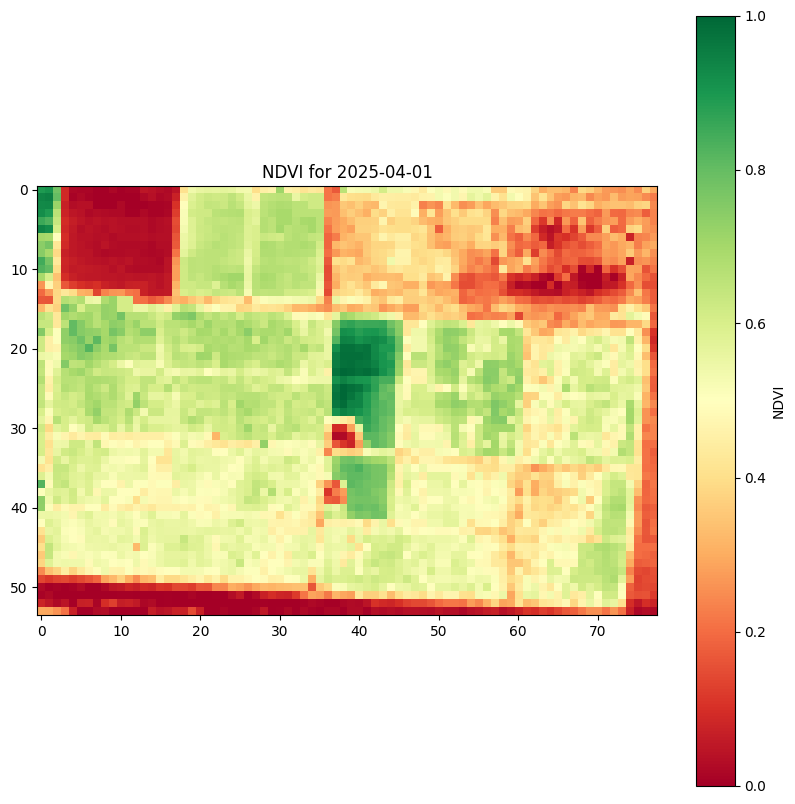

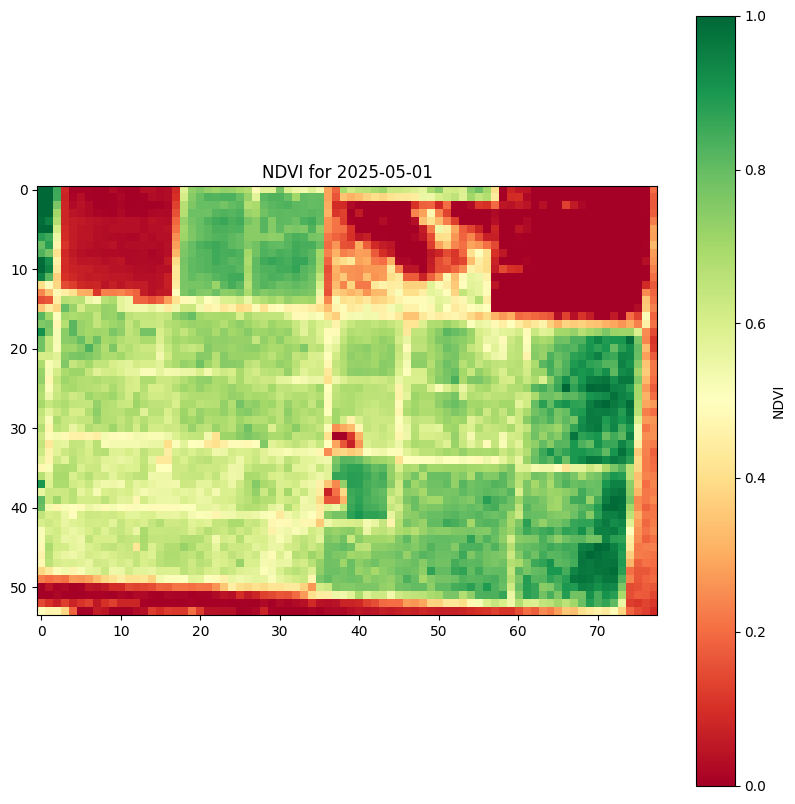

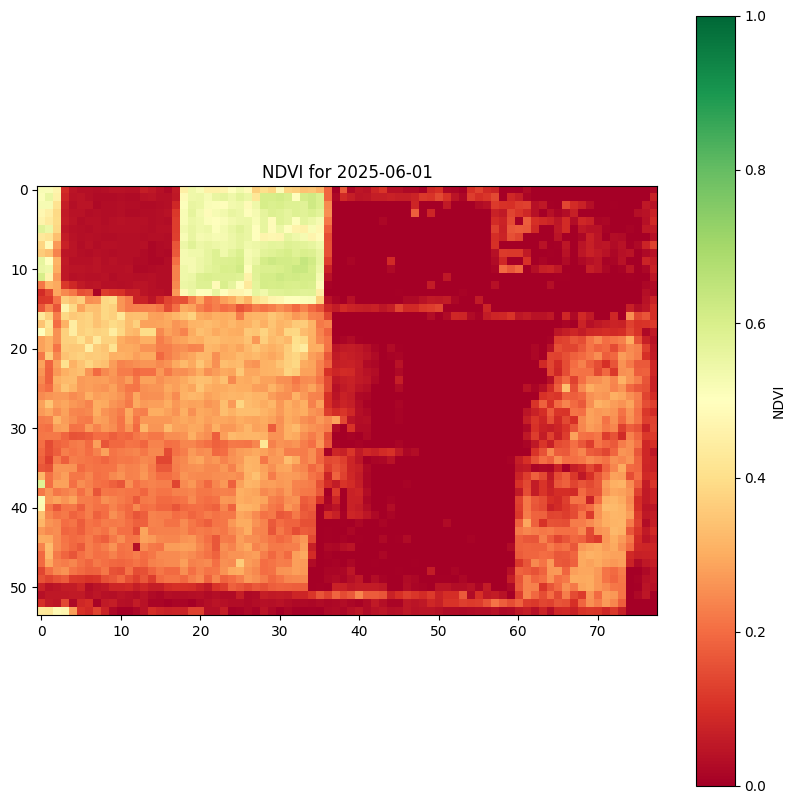

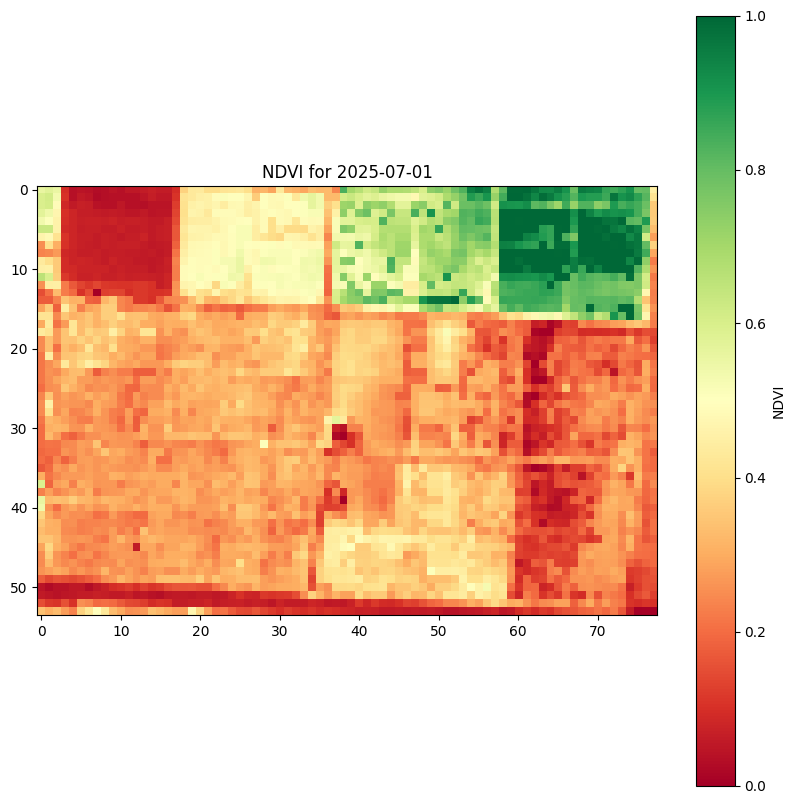

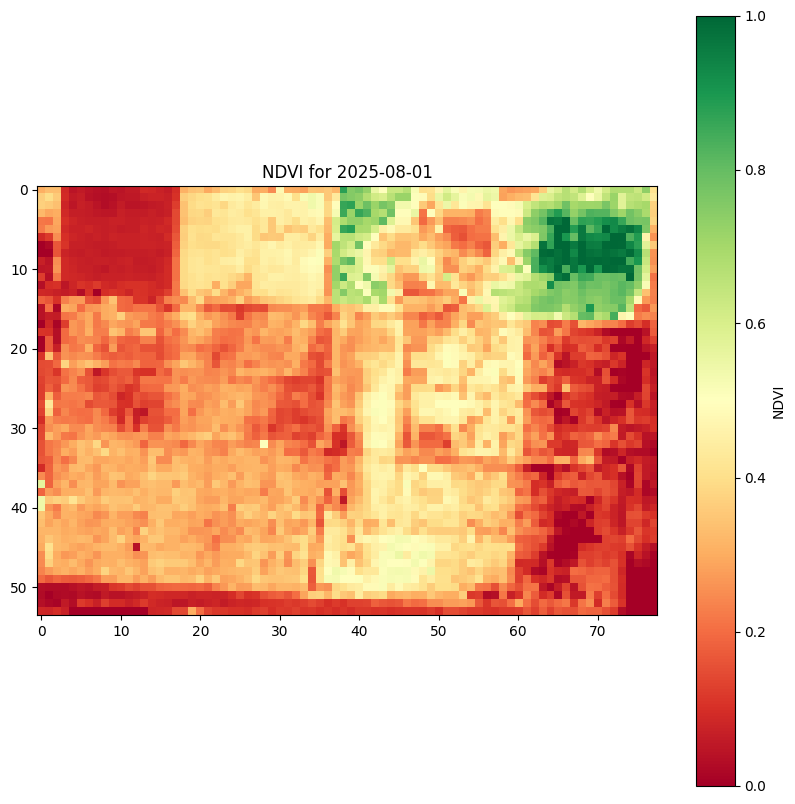

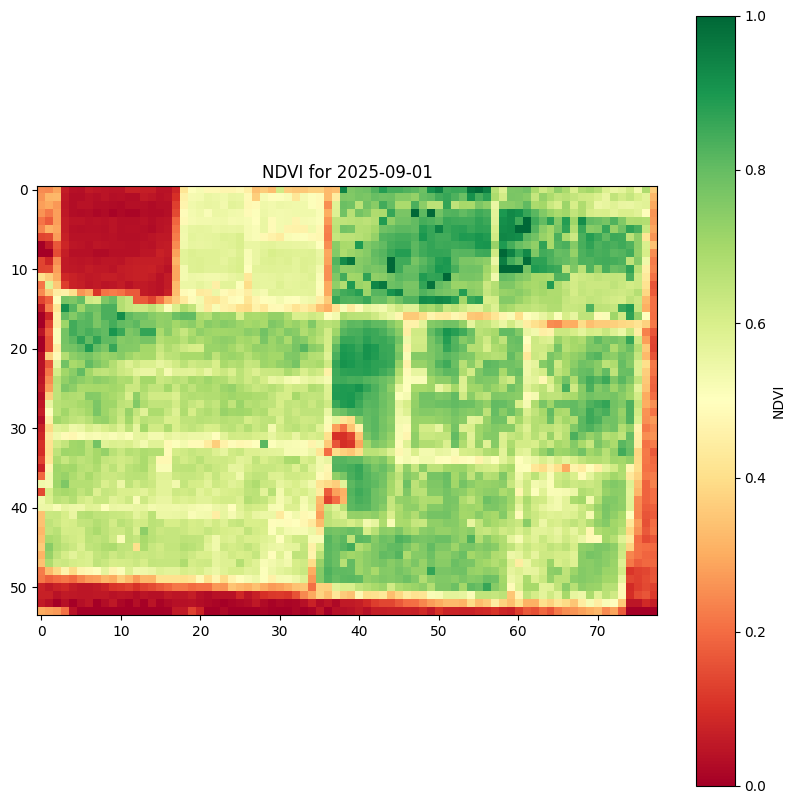

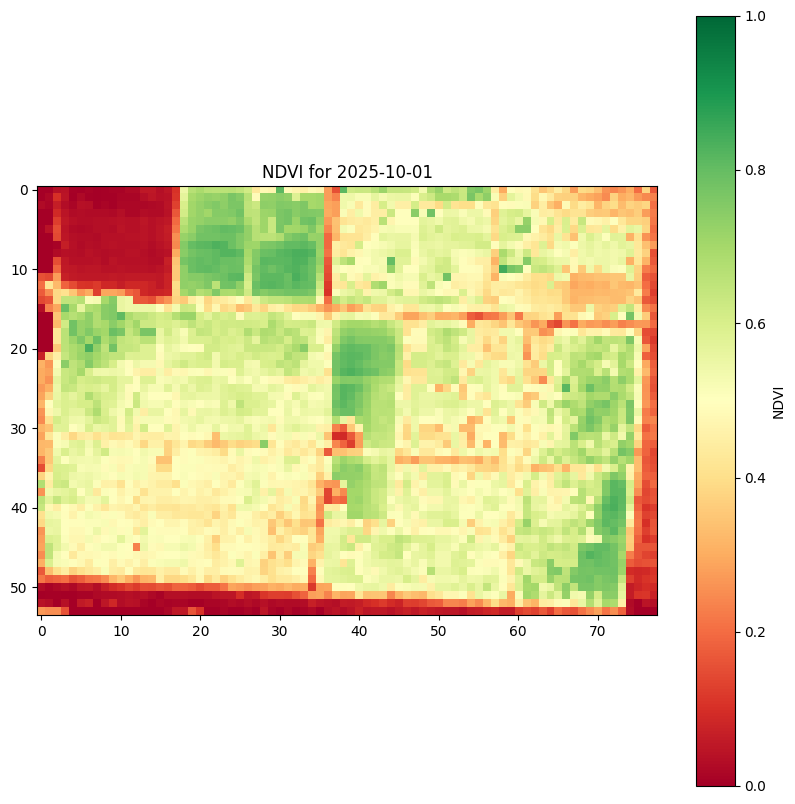

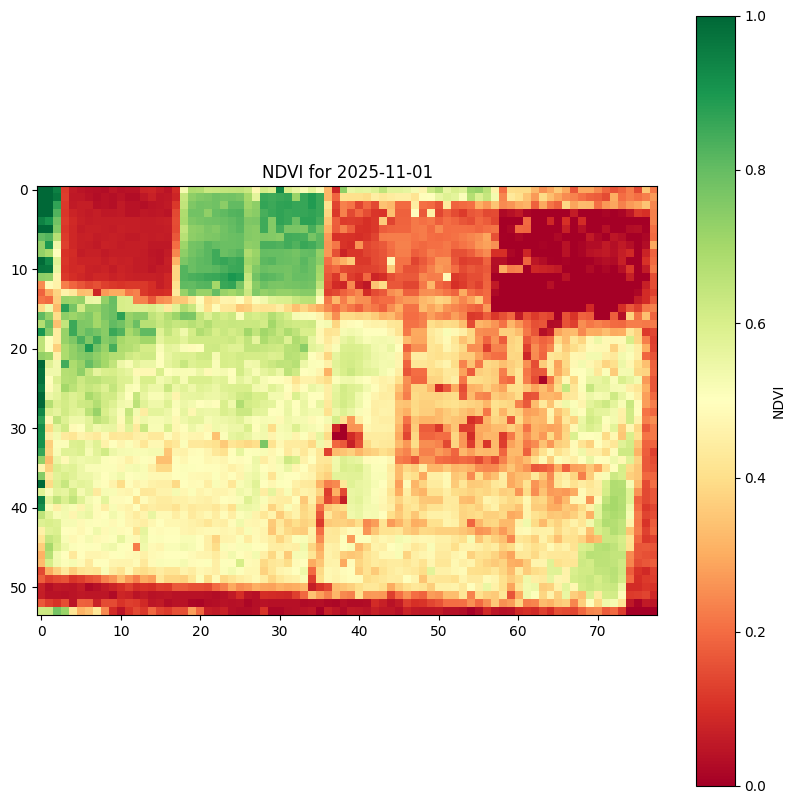

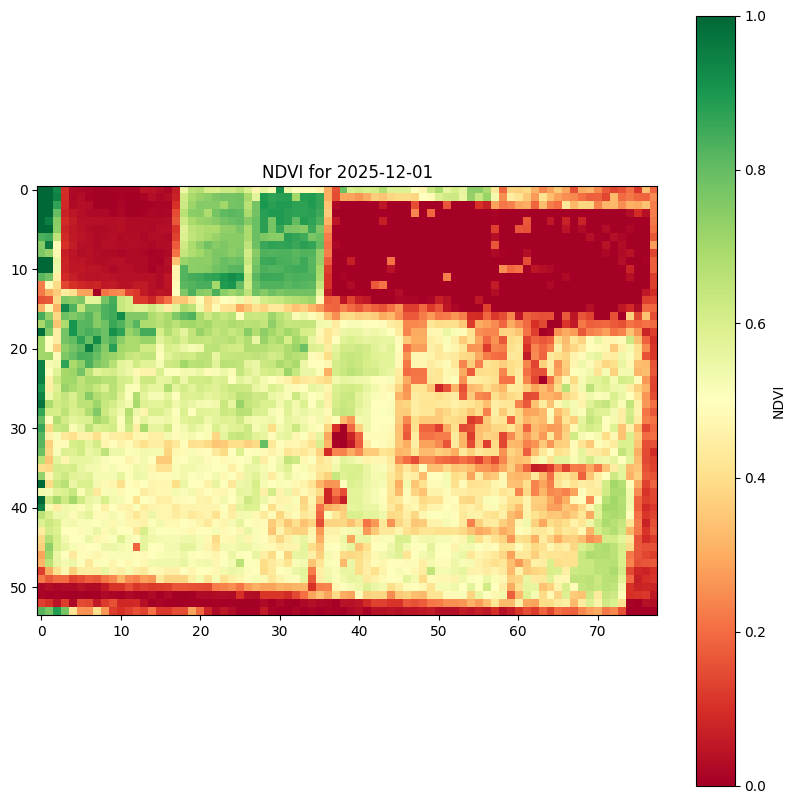

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_ndvi_for_date(date_col):
    # Extract NDVI data for the specified date
    ndvi_data = df_results[date_col].values.reshape(l, c)

    # Create the plot
    plt.figure(figsize=(10, 10))  # Adjust figure size as needed
    plt.imshow(ndvi_data, cmap='RdYlGn', vmin=0, vmax=1)  # Use RdYlGn colormap and set limits
    plt.title(f'NDVI for {date_col}')
    plt.colorbar(label='NDVI')
    plt.show()


for col in future_columns:
    plot_ndvi_for_date(col)


## Thank you! See you in the next Chapter!